In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scripts.preprocessing.data_loader import ThermalDataset
import torch
from scripts.utils.utils import *

from torch.utils.data import DataLoader
import torch
import json
from scripts.models.R2AU_dynamic import R2AttU_Net
from scripts.preprocessing.data_loader import ThermalDataset

import os
from pathlib import Path
from dotenv import load_dotenv

import os 
from PIL import Image


In [ ]:
load_dotenv()
ROOT_DIR = Path(os.getenv("ROOT_DIR"))

model_dir = ROOT_DIR / "best_model_saved"
model_path = f"{model_dir}/best_model.pth"
config_path = f"{model_dir}/config.json"

with open(config_path, "r") as f:
    config = json.load(f)

model = R2AttU_Net(
    img_ch=1,
    output_ch=3,
    t=config["t"],
    base_filters=config["base_filters"],
    depth=config["depth"]
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device).eval()

R2AttU_Net(
  (Maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder): ModuleList(
    (0): RRCNN_block(
      (Conv_1x1): Conv2d(1, 8, kernel_size=(1, 1), stride=(1, 1))
      (RCNN): Sequential(
        (0): Recurrent_block(
          (conv): Sequential(
            (0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
        )
        (1): Recurrent_block(
          (conv): Sequential(
            (0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
        )
      )
    )
    (1): RRCNN_block(
      (Conv_1x1): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
      (RCNN): Sequential(
        (0): Recurrent_block(
          (c

## Test and labels preprocessing

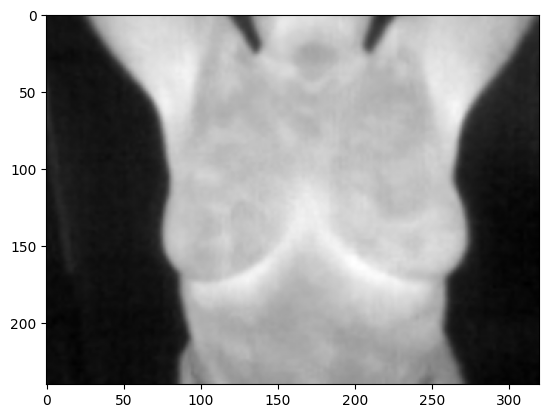

In [ ]:
images_path = ROOT_DIR / "data/test Flir/processed/"
output_images_path = ROOT_DIR / "data/test Flir/processed_numpy/"

all_images_path = os.listdir(images_path)

if not os.path.exists(output_images_path):
    os.makedirs(output_images_path)

for image_name in all_images_path:
    image_path = os.path.join(images_path, image_name)
    if not os.path.isfile(image_path):
        continue

    if not image_name.endswith('.png'):
        continue
    image = Image.open(image_path)
    image_array = np.array(image)

    output_path = os.path.join(output_images_path, f"{os.path.splitext(image_name)[0]}.npy")
    np.save(output_path, image_array)

random_image_path = os.listdir(output_images_path)[0]
random_image = np.load(os.path.join(output_images_path, random_image_path))
plt.imshow(random_image, cmap='gray')

In [ ]:
labels_path = ROOT_DIR / "data/test Flir/labels/"
left_path = os.path.join(labels_path, "left_breast/")
right_path = os.path.join(labels_path, "right_breast/")
masks_output_path = ROOT_DIR / "data/test Flir/labels/labels_merged_numpy/"

if not os.path.exists(masks_output_path):
    os.makedirs(masks_output_path)

all_right_masks = os.listdir(right_path)
all_left_masks = os.listdir(left_path)
all_right_masks.sort()
all_left_masks.sort()

import tifffile as tiff

for i in range(len(all_right_masks)):
    print(os.path.join(right_path, all_right_masks[i]))
    right_mask = np.array(Image.open(os.path.join(right_path, all_right_masks[i])))
    left_mask = np.array(Image.open(os.path.join(left_path, all_left_masks[i])))

    if right_mask.size != left_mask.size:
        print(f"Shapes do not match for {all_right_masks[i]} and {all_left_masks[i]}")
        continue

    merged_mask = np.zeros_like(right_mask, dtype=np.uint8)
    merged_mask[right_mask > 0] = 1
    merged_mask[left_mask > 0] = 1

    current_mask_name = all_right_masks[i].split('.')[0]  
    mask_new_name = f"{current_mask_name}_merged.npy"
    merged_mask_path = os.path.join(masks_output_path, mask_new_name)
    np.save(merged_mask_path, merged_mask)


data/test Flir/labels/right_breast/img-000_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-001_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-002_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-003_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-004_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-005_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-006_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-007_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-008_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-009_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-010_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-011_processed_right-breast.ome.tiff
data/test Flir/labels/right_breast/img-012_processed_right-breast.ome.tiff
data/test Flir/labels/rig

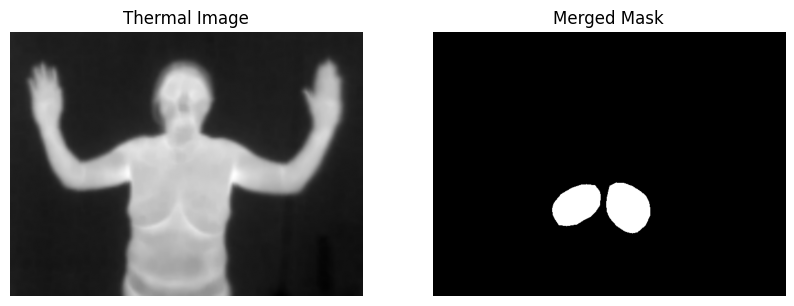

In [ ]:
output_images = os.listdir(output_images_path)
masks = os.listdir(masks_output_path)
output_images.sort()
masks.sort()

import random
idx = random.randint(0, len(output_images) - 1)
first_image = output_images[idx]
first_mask = masks[idx]

image_array = np.load(os.path.join(output_images_path, first_image))
mask_array = np.load(os.path.join(masks_output_path, first_mask))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_array, cmap='gray')
plt.title('Thermal Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mask_array, cmap='gray')
plt.title('Merged Mask')
plt.axis('off')
plt.show()

## Random Image preprocessing test

In [6]:
test_path = 'data/test Flir/processed_numpy/'
masks_path = 'data/test Flir/labels/labels_merged_numpy/'

In [ ]:
test_dataset = ThermalDataset(images_dir=test_path, masks_dir=masks_path, height=256, width=384)
test_loader  = DataLoader(test_dataset,
                          batch_size=config["batch_size"],
                          shuffle=True,
                          num_workers=4,
                          pin_memory=True)

print(f"Test set size: {len(test_loader.dataset)}")

Test set size: 21


torch.Size([1, 256, 384]) torch.Size([256, 384])
0.0 1.0 0.0 1.0
Unique values in the mask: [0. 1.] Counts: [93549  4755]


(-0.5, 383.5, 255.5, -0.5)

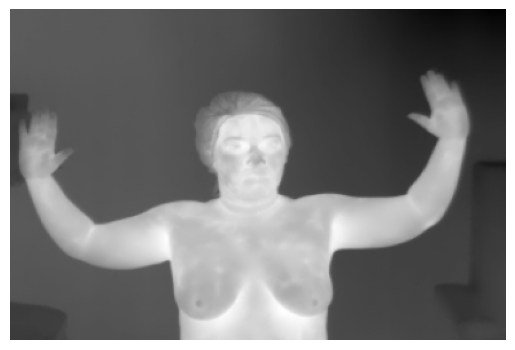

In [ ]:
idx = random.randint(0, len(test_loader.dataset) - 1)
imageprova, mask = test_dataset[0]
print(imageprova.shape, mask.shape)
imageprova = imageprova[0].numpy()
mask_prova = mask.numpy()
print(np.min(imageprova), np.max(imageprova), np.min(mask_prova), np.max(mask_prova))
unique_values, counts = np.unique(mask_prova, return_counts=True)
print("Unique values in the mask:", unique_values, "Counts:", counts)
plt.imshow(imageprova, cmap='gray')
plt.axis('off')

In [ ]:
all_images, all_preds, all_gt, all_images_logits = [], [], [], []
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        outputs = model(images)
        all_images_logits.append(outputs.cpu())
        print(outputs[0].shape, masks[0].shape)

        preds   = torch.sigmoid(outputs).cpu()  
        preds   = (preds < 0.5).float()
        all_images.append(images.cpu())
        all_preds.append(preds)
        all_gt.append(masks.cpu())

print(all_images[0].shape, all_preds[0].shape, all_gt[0].shape)

torch.Size([3, 256, 384]) torch.Size([256, 384])
torch.Size([3, 256, 384]) torch.Size([256, 384])
torch.Size([3, 256, 384]) torch.Size([256, 384])
torch.Size([3, 256, 384]) torch.Size([256, 384])
torch.Size([3, 256, 384]) torch.Size([256, 384])
torch.Size([3, 256, 384]) torch.Size([256, 384])
torch.Size([4, 1, 256, 384]) torch.Size([4, 3, 256, 384]) torch.Size([4, 256, 384])


In [ ]:
all_images = torch.cat(all_images, dim=0).numpy()
all_preds  = torch.cat(all_preds,  dim=0).numpy()
all_gt    = torch.cat(all_gt,    dim=0).numpy()
all_images_logits = torch.cat(all_images_logits, dim=0).numpy()

print(all_images.shape, all_preds.shape, all_gt.shape)

pred_temp = all_preds[0][0]
print(pred_temp.shape, np.min(pred_temp), np.max(pred_temp), np.mean(pred_temp))
unique_values, counts = np.unique(pred_temp, return_counts=True)
print("Unique values in the prediction:", unique_values, "Counts:", counts)

(21, 1, 256, 384) (21, 3, 256, 384) (21, 256, 384)
(256, 384) 0.0 1.0 0.05432129
Unique values in the prediction: [0. 1.] Counts: [92964  5340]


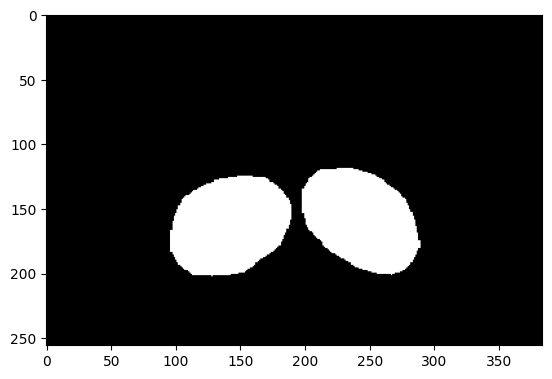

In [ ]:
idx = random.randint(0, len(all_gt) - 1)
random_gt = all_gt[idx]
plt.imshow(random_gt, cmap='gray')

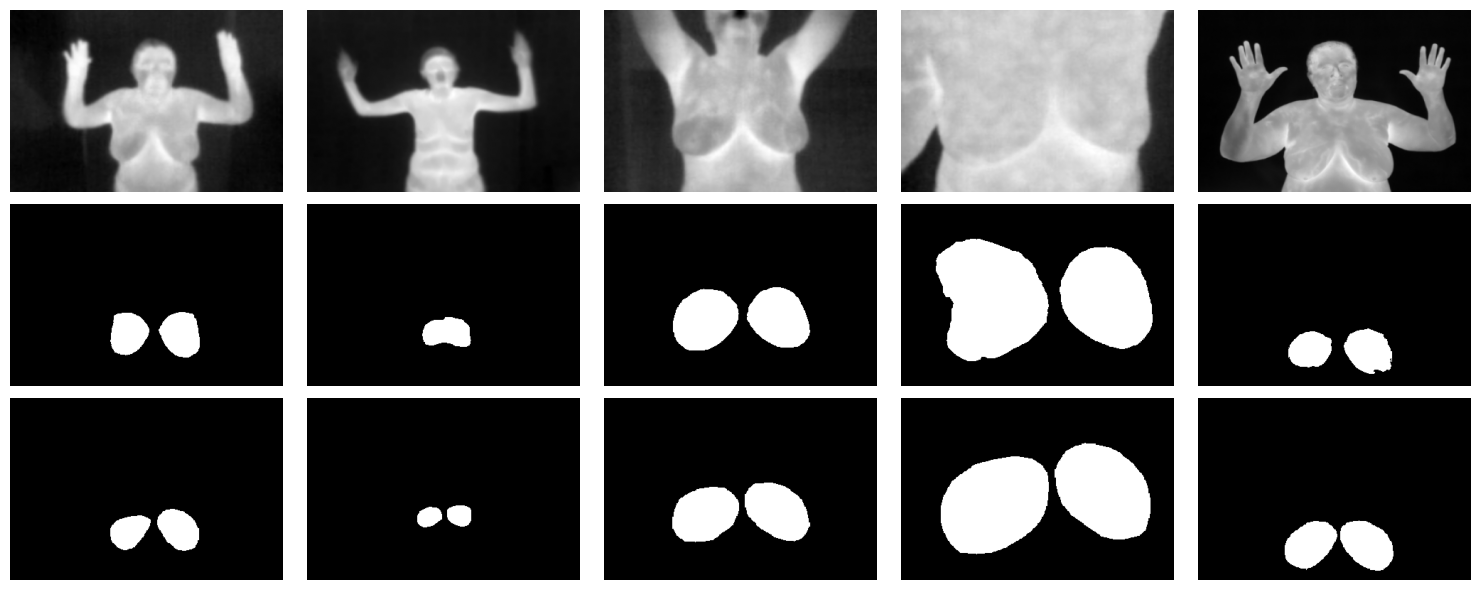

In [ ]:
indices = list(range(5))

fig, axes = plt.subplots(3, 5, figsize=(15, 6))
axes[0, 0].set_ylabel(f"Raw Image")
axes[1, 0].set_ylabel(f"Predicted Mask")
axes[2, 0].set_ylabel(f"Ground Truth Mask")
for i, idx in enumerate(indices):
    axes[0, i].imshow(all_images[idx, 0], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(all_preds[idx, 0], cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(all_gt[idx], cmap='gray')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

## Test Metrics

In [ ]:
import torch
from scripts.models.metrics import get_metrics

all_preds_fixed = all_preds[:, 0:1, :, :] 
all_images_logits = all_images_logits[:, 0:1, :, :]  
all_gt_fixed = all_gt[:, None, :, :]

print(all_preds_fixed.shape, all_gt_fixed.shape, all_images_logits.shape)

idx = random.randint(0, len(all_preds_fixed) - 1)
image = all_images[idx, 0]  
gt_mask = all_gt_fixed[idx, 0]
print(np.min(image), np.max(image), np.min(gt_mask), np.max(gt_mask))
print("all_preds unique values:", np.unique(all_preds_fixed))

/home/gabrielepassoni/anaconda3/envs/bcxtt/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/gabrielepassoni/anaconda3/envs/bcxtt/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c107WarningC1ENS_7variantIJNS0_11UserWarningENS0_18DeprecationWarningEEEERKNS_14SourceLocationENSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEEb'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


(21, 1, 256, 384) (21, 1, 256, 384) (21, 1, 256, 384)
0.0 1.0 0.0 1.0
all_preds unique values: [0. 1.]


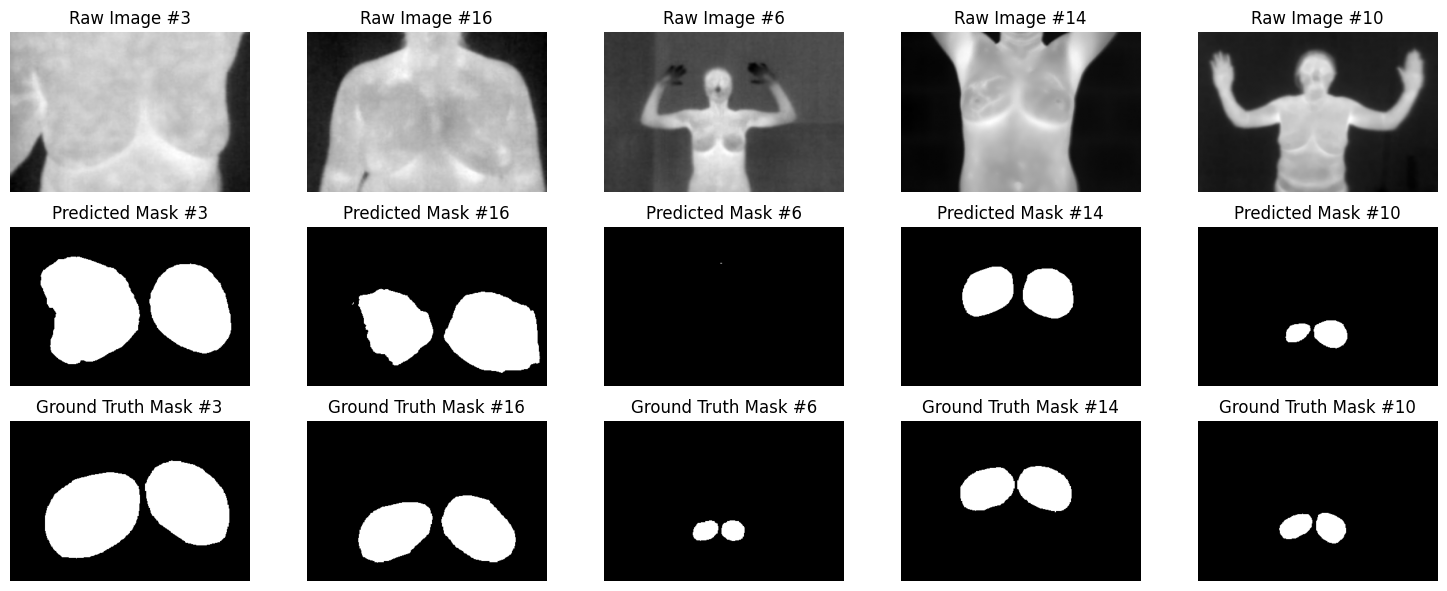

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(15, 6))
indices = random.sample(range(len(all_images)), 5)
for i, idx in enumerate(indices):
    image = all_images[idx, 0]
    axes[0, i].imshow(image, cmap='gray')
    axes[0, i].set_title(f"Raw Image #{idx}")
    axes[0, i].axis('off')

    logits = torch.tensor(all_preds_fixed[idx, 0])  # logits
    probs = torch.sigmoid(logits).numpy()
    axes[1, i].imshow(probs, cmap='gray')
    axes[1, i].set_title(f"Predicted Mask #{idx}")
    axes[1, i].axis('off')

    gt_mask = all_gt_fixed[idx, 0]
    axes[2, i].imshow(gt_mask, cmap='gray')
    axes[2, i].set_title(f"Ground Truth Mask #{idx}")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
all_preds_tensor = torch.tensor(all_preds_fixed, dtype=torch.float32)
all_gt_tensor = torch.tensor(all_gt_fixed, dtype=torch.float32)
all_images_logits_tensor = torch.tensor(all_images_logits, dtype=torch.float32)

In [ ]:
idx = random.randint(0, len(all_preds_fixed) - 1)
pred_mask = all_preds_fixed[idx, 0]  
gt_mask = all_gt_fixed[idx, 0]  
print("Pred mask shape:", pred_mask.shape)
print("GT mask shape:", gt_mask.shape)
np.sum(pred_mask), np.sum(gt_mask)

Pred mask shape: (256, 384)
GT mask shape: (256, 384)


(0.0, 2584.0)

In [ ]:
import torch
from sklearn.metrics import roc_auc_score

def compute_metrics_torch(all_preds_tensor, all_gt_tensor):
    # Flatten
    y_pred_flat = all_preds_tensor.view(-1).cpu().numpy()
    y_true_flat = all_gt_tensor.view(-1).cpu().numpy()
    print("y_pred_flat shape:", y_pred_flat.shape)
    print("y_true_flat shape:", y_true_flat.shape)

    TP = ((y_true_flat == 1) & (y_pred_flat == 1)).sum()
    TN = ((y_true_flat == 0) & (y_pred_flat == 0)).sum()
    FP = ((y_true_flat == 0) & (y_pred_flat == 1)).sum()
    FN = ((y_true_flat == 1) & (y_pred_flat == 0)).sum()

    eps = 1e-8
    precision = TP / (TP + FP + eps)
    recall = TP / (TP + FN + eps)
    specificity = TN / (TN + FP + eps)
    dice = 2 * TP / (2 * TP + FP + FN + eps)
    iou = TP / (TP + FP + FN + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    try:
        auc = roc_auc_score(y_true_flat, y_pred_flat)
    except:
        auc = float('nan')

    return {
        "Dice": dice,
        "IoU": iou,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "AUC": auc
    }

metrics = compute_metrics_torch(all_preds_tensor, all_gt_tensor)
print(metrics)


y_pred_flat shape: (2064384,)
y_true_flat shape: (2064384,)
{'Dice': 0.8379008999322676, 'IoU': 0.7210236200023139, 'Precision': 0.8200581148487935, 'Recall': 0.856537399540282, 'F1': 0.8379008949346188, 'Specificity': 0.9730005828009404, 'AUC': 0.9147689911706304}


In [ ]:
def compute_metrics_per_image(all_preds_tensor, all_gt_tensor):
    metrics_list = []

    for i in range(all_preds_tensor.shape[0]):
        pred = all_preds_tensor[i].view(-1).cpu().numpy()
        gt = all_gt_tensor[i].view(-1).cpu().numpy()

        TP = np.sum((gt == 1) & (pred == 1))
        TN = np.sum((gt == 0) & (pred == 0))
        FP = np.sum((gt == 0) & (pred == 1))
        FN = np.sum((gt == 1) & (pred == 0))

        eps = 1e-8
        precision = TP / (TP + FP + eps)
        recall = TP / (TP + FN + eps)
        specificity = TN / (TN + FP + eps)
        dice = 2 * TP / (2 * TP + FP + FN + eps)
        iou = TP / (TP + FP + FN + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)

        try:
            auc = roc_auc_score(gt, pred)
        except:
            auc = float('nan')

        metrics_list.append({
            "image": i,
            "Dice": dice,
            "IoU": iou,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Specificity": specificity,
            "AUC": auc
        })

    return metrics_list

metrics_per_image = compute_metrics_per_image(all_preds_tensor, all_gt_tensor)

for m in metrics_per_image:
    print(f"Image {m['image']}:")
    for k, v in m.items():
        if k != "image":
            print(f"  {k}: {v:.4f}")


Image 0:
  Dice: 0.8785
  IoU: 0.7833
  Precision: 0.8110
  Recall: 0.9582
  F1: 0.8785
  Specificity: 0.9892
  AUC: 0.9737
Image 1:
  Dice: 0.4194
  IoU: 0.2654
  Precision: 0.3598
  Recall: 0.5028
  F1: 0.4194
  Specificity: 0.9850
  AUC: 0.7439
Image 2:
  Dice: 0.9402
  IoU: 0.8872
  Precision: 0.9168
  Recall: 0.9649
  F1: 0.9402
  Specificity: 0.9888
  AUC: 0.9768
Image 3:
  Dice: 0.8741
  IoU: 0.7764
  Precision: 0.8169
  Recall: 0.9400
  F1: 0.8741
  Specificity: 0.9083
  AUC: 0.9242
Image 4:
  Dice: 0.8605
  IoU: 0.7552
  Precision: 0.9947
  Recall: 0.7583
  F1: 0.8605
  Specificity: 0.9997
  AUC: 0.8790
Image 5:
  Dice: 0.0000
  IoU: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000
  Specificity: 1.0000
  AUC: 0.5000
Image 6:
  Dice: 0.0000
  IoU: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000
  Specificity: 1.0000
  AUC: 0.5000
Image 7:
  Dice: 0.9060
  IoU: 0.8281
  Precision: 0.8517
  Recall: 0.9677
  F1: 0.9060
  Specificity: 0.9689
  AUC: 0.9683
Image 8: